# Project 2: Text & Document Visualization

## Top 5 vs Bottom 5 State of the Union Vocabulary Analysis

This version extends the original project with:

- **Term Frequency (TF)** for the top 5 and bottom 5 speeches
- **Term Weight** as a normalized share of each group's processed tokens
- **Mean TF-IDF** to show which words are most distinctive in each group
- **Tables + bar-chart visualizations** for all three metrics
- **Interactive word clouds** whose tooltips show **raw count, term weight, percentage of group tokens, and mean TF-IDF**

**How the groups are defined:** after sorting by year, the analysis compares the **first 5 speeches** in the dataset against the **last 5 speeches** in the dataset.


In [1]:

from pathlib import Path
import ast
import json
import os
import re
from collections import Counter

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, display
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer
from wordcloud import WordCloud

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

plt.rcParams["figure.dpi"] = 120

def find_data_file(filename="state_ofthe_union_texts.csv"):
    candidates = [
        Path(filename),
        Path.cwd() / filename,
        Path("/mnt/data") / filename,
        Path("/content") / filename,
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find {filename}. Place it in the notebook directory, /mnt/data, or /content."
    )

data_path = find_data_file()
df = pd.read_csv(data_path).sort_values("Year").reset_index(drop=True)

top_5_df = df.head(5).copy()
bottom_5_df = df.tail(5).copy()

display(HTML(f"<p><b>Loaded file:</b> {data_path}</p>"))
display(df[["President", "Year", "Title"]].head(3))


,President,Year,Title
0,George Washington,1790,First State of the Union Address
1,George Washington,1790,Second State of the Union Address
2,George Washington,1791,Third State of the Union Address


In [2]:

display(HTML("<h2>Speech subsets used in the comparison</h2>"))

display(HTML("<h3>Top 5 speeches (earliest after sorting by year)</h3>"))
display(top_5_df[["President", "Year", "Title"]])

display(HTML("<h3>Bottom 5 speeches (latest after sorting by year)</h3>"))
display(bottom_5_df[["President", "Year", "Title"]])


,President,Year,Title
0,George Washington,1790,First State of the Union Address
1,George Washington,1790,Second State of the Union Address
2,George Washington,1791,Third State of the Union Address
3,George Washington,1792,Fourth State of the Union Address
4,George Washington,1793,Fifth State of the Union Address


,President,Year,Title
214,Barack Obama,2015,Barack Obama's Seventh State of the Union Address
215,Barack Obama,2016,Barack Obama's Eighth State of the Union Address
216,Donald Trump,2017,Donald Trump's First State of the Union Address
217,Donald Trump,2018,Donald Trump's Second State of the Union Address
218,Donald Trump,2019,Donald Trump's Third State of the Union Address


## Text Preprocessing

To keep the comparison readable, the notebook uses light preprocessing instead of aggressive stemming:

- converts the list-like text field into plain text
- lowercases the text
- collapses **“United States”** into **`unitedstates`**
- removes punctuation and numbers
- removes English stopwords plus repeated speech boilerplate
- applies light normalization for a few plural/singular pairs such as `jobs → job` and `families → family`

### Metric Definitions

- **Term Frequency (TF):** raw count of a word in the selected group
- **Term Weight:** `TF / total processed tokens in that group`
- **% of Group Tokens:** `Term Weight × 100`
- **Mean TF-IDF:** average TF-IDF score for that term across the speeches in each group, using the full corpus as the IDF reference


In [3]:

custom_stopwords = set(ENGLISH_STOP_WORDS).union({
    "may", "upon", "made", "one", "every", "year", "years", "new", "also", "must",
    "shall", "said", "make", "great", "can", "would", "will", "now", "let", "us",
    "mr", "speaker", "vice", "president", "member", "members",
    "fellow", "house", "senate", "state", "union", "address",
    "it's", "that's", "we've", "don't", "can't", "i'm", "you're",
    "they're", "we're", "isn't", "won't"
})

normalization_map = {
    "americans": "america",
    "american": "america",
    "jobs": "job",
    "workers": "worker",
    "families": "family",
    "laws": "law",
    "children": "child",
    "businesses": "business",
    "communities": "community",
    "taxes": "tax",
    "schools": "school",
    "nations": "nation",
    "countries": "country",
    "governments": "government",
}

def parse_text(value):
    if isinstance(value, str):
        try:
            parsed = ast.literal_eval(value)
            if isinstance(parsed, list):
                return " ".join(map(str, parsed))
        except Exception:
            return value
    return str(value)

def preprocess_tokens(text):
    text = parse_text(text).lower()
    text = re.sub(r"united\s+states", "unitedstates", text)
    text = text.replace("-", " ")
    tokens = re.findall(r"[a-z']+", text)

    cleaned = []
    for token in tokens:
        token = token.strip("'")
        if not token or len(token) <= 2 or token in custom_stopwords:
            continue
        token = normalization_map.get(token, token)
        if not token or len(token) <= 2 or token in custom_stopwords:
            continue
        cleaned.append(token)
    return cleaned

df["tokens"] = df["Text"].apply(preprocess_tokens)
df["processed_text"] = df["tokens"].apply(" ".join)

top_tokens = top_5_df["Text"].apply(preprocess_tokens).tolist()
bottom_tokens = bottom_5_df["Text"].apply(preprocess_tokens).tolist()

def build_term_metrics(token_lists):
    all_tokens = [token for doc in token_lists for token in doc]
    total_tokens = len(all_tokens)
    counts = Counter(all_tokens)

    metrics = pd.DataFrame({
        "term": list(counts.keys()),
        "term_frequency": list(counts.values())
    })
    metrics["term_weight"] = metrics["term_frequency"] / total_tokens
    metrics["term_weight_pct"] = metrics["term_weight"] * 100

    metrics = metrics.sort_values(
        ["term_weight", "term_frequency", "term"],
        ascending=[False, False, True]
    ).reset_index(drop=True)

    return metrics, total_tokens

top_metrics, top_total_tokens = build_term_metrics(top_tokens)
bottom_metrics, bottom_total_tokens = build_term_metrics(bottom_tokens)

corpus_summary = pd.DataFrame({
    "Group": ["Top 5 speeches", "Bottom 5 speeches"],
    "Speech Count": [len(top_tokens), len(bottom_tokens)],
    "Processed Tokens": [top_total_tokens, bottom_total_tokens],
    "Unique Terms": [top_metrics.shape[0], bottom_metrics.shape[0]],
    "Average Tokens per Speech": [
        round(top_total_tokens / len(top_tokens), 1),
        round(bottom_total_tokens / len(bottom_tokens), 1),
    ],
})

display(HTML("<h2>Corpus summary after preprocessing</h2>"))
display(corpus_summary)


,Group,Speech Count,Processed Tokens,Unique Terms,Average Tokens per Speech
0,Top 5 speeches,5,3449,1640,689.8
1,Bottom 5 speeches,5,12339,3781,2467.8


In [4]:

# Compute TF-IDF on the full corpus, then average scores within the top-5 and bottom-5 subsets.
# min_df=5 suppresses very rare terms so the comparison emphasizes recurring vocabulary.
vectorizer = TfidfVectorizer(token_pattern=r"(?u)\b[a-z']+\b", min_df=5)
tfidf_matrix = vectorizer.fit_transform(df["processed_text"])
tfidf_terms = vectorizer.get_feature_names_out()

top_idx = top_5_df.index.to_list()
bottom_idx = bottom_5_df.index.to_list()

top_mean_tfidf = np.asarray(tfidf_matrix[top_idx].mean(axis=0)).ravel()
bottom_mean_tfidf = np.asarray(tfidf_matrix[bottom_idx].mean(axis=0)).ravel()

tfidf_lookup = pd.DataFrame({
    "term": tfidf_terms,
    "top5_mean_tfidf": top_mean_tfidf,
    "bottom5_mean_tfidf": bottom_mean_tfidf,
})

top_metrics = (
    top_metrics
    .merge(tfidf_lookup[["term", "top5_mean_tfidf"]], on="term", how="left")
    .rename(columns={"top5_mean_tfidf": "mean_tfidf"})
    .fillna({"mean_tfidf": 0})
)

bottom_metrics = (
    bottom_metrics
    .merge(tfidf_lookup[["term", "bottom5_mean_tfidf"]], on="term", how="left")
    .rename(columns={"bottom5_mean_tfidf": "mean_tfidf"})
    .fillna({"mean_tfidf": 0})
)

comparison = (
    top_metrics.rename(columns={
        "term_frequency": "tf_top5",
        "term_weight": "weight_top5",
        "term_weight_pct": "weight_pct_top5",
        "mean_tfidf": "tfidf_top5"
    })
    .merge(
        bottom_metrics.rename(columns={
            "term_frequency": "tf_bottom5",
            "term_weight": "weight_bottom5",
            "term_weight_pct": "weight_pct_bottom5",
            "mean_tfidf": "tfidf_bottom5"
        }),
        on="term",
        how="outer"
    )
    .fillna(0)
)

comparison["weight_gap_pct_points"] = comparison["weight_pct_top5"] - comparison["weight_pct_bottom5"]
comparison["tfidf_gap"] = comparison["tfidf_top5"] - comparison["tfidf_bottom5"]

display(HTML("<p><b>TF-IDF note:</b> scores are averaged within each group after computing IDF from the full State of the Union corpus.</p>"))


In [5]:

display(HTML("<h2>Tables</h2>"))

def format_metrics_table(metrics_df, n=15):
    view = metrics_df.head(n).copy()
    view = view[["term", "term_frequency", "term_weight", "term_weight_pct", "mean_tfidf"]]
    view.columns = ["Term", "Term Frequency", "Term Weight", "% of Group Tokens", "Mean TF-IDF"]
    view["Term Frequency"] = view["Term Frequency"].astype(int)
    view["Term Weight"] = view["Term Weight"].map(lambda x: f"{x:.4f}")
    view["% of Group Tokens"] = view["% of Group Tokens"].map(lambda x: f"{x:.2f}%")
    view["Mean TF-IDF"] = view["Mean TF-IDF"].map(lambda x: f"{x:.4f}")
    return view

display(HTML("<h3>Top 15 terms in the top 5 speeches (ranked by term weight)</h3>"))
display(format_metrics_table(top_metrics, n=15))

display(HTML("<h3>Top 15 terms in the bottom 5 speeches (ranked by term weight)</h3>"))
display(format_metrics_table(bottom_metrics, n=15))

top_distinctive = (
    comparison.sort_values(["tfidf_gap", "weight_gap_pct_points"], ascending=[False, False])
    .head(10)
    .copy()
)
bottom_distinctive = (
    comparison.sort_values(["tfidf_gap", "weight_gap_pct_points"], ascending=[True, True])
    .head(10)
    .copy()
)

distinctive_table = pd.concat(
    [
        top_distinctive[["term", "tf_top5", "weight_pct_top5", "tfidf_top5"]]
        .rename(columns={
            "term": "Top 5 distinctive term",
            "tf_top5": "TF (Top 5)",
            "weight_pct_top5": "% Tokens (Top 5)",
            "tfidf_top5": "Mean TF-IDF (Top 5)",
        })
        .reset_index(drop=True),
        bottom_distinctive[["term", "tf_bottom5", "weight_pct_bottom5", "tfidf_bottom5"]]
        .rename(columns={
            "term": "Bottom 5 distinctive term",
            "tf_bottom5": "TF (Bottom 5)",
            "weight_pct_bottom5": "% Tokens (Bottom 5)",
            "tfidf_bottom5": "Mean TF-IDF (Bottom 5)",
        })
        .reset_index(drop=True),
    ],
    axis=1,
)

distinctive_table["TF (Top 5)"] = distinctive_table["TF (Top 5)"].astype(int)
distinctive_table["TF (Bottom 5)"] = distinctive_table["TF (Bottom 5)"].astype(int)

for col in ["% Tokens (Top 5)", "% Tokens (Bottom 5)"]:
    distinctive_table[col] = distinctive_table[col].map(lambda x: f"{x:.2f}%")

for col in ["Mean TF-IDF (Top 5)", "Mean TF-IDF (Bottom 5)"]:
    distinctive_table[col] = distinctive_table[col].map(lambda x: f"{x:.4f}")

display(HTML("<h3>Most distinctive terms by mean TF-IDF gap</h3>"))
display(distinctive_table)


,Term,Term Frequency,Term Weight,% of Group Tokens,Mean TF-IDF
0,unitedstates,49,0.0142,1.42%,0.1373
1,public,32,0.0093,0.93%,0.0982
2,law,30,0.0087,0.87%,0.0861
3,citizens,21,0.0061,0.61%,0.0665
4,government,20,0.0058,0.58%,0.0596
5,measures,19,0.0055,0.55%,0.0701
6,nation,19,0.0055,0.55%,0.0530
7,present,18,0.0052,0.52%,0.0592
8,provision,18,0.0052,0.52%,0.0722
9,peace,17,0.0049,0.49%,0.0505


,Term,Term Frequency,Term Weight,% of Group Tokens,Mean TF-IDF
0,america,354,0.0287,2.87%,0.3701
1,country,101,0.0082,0.82%,0.1011
2,people,94,0.0076,0.76%,0.0967
3,job,84,0.0068,0.68%,0.1658
4,world,80,0.0065,0.65%,0.0889
5,tonight,74,0.0060,0.60%,0.1896
6,work,72,0.0058,0.58%,0.0789
7,family,65,0.0053,0.53%,0.0902
8,time,64,0.0052,0.52%,0.0621
9,nation,63,0.0051,0.51%,0.0633


,Top 5 distinctive term,TF (Top 5),% Tokens (Top 5),Mean TF-IDF (Top 5),Bottom 5 distinctive term,TF (Bottom 5),% Tokens (Bottom 5),Mean TF-IDF (Bottom 5)
0,unitedstates,49,1.42%,0.1373,america,354,2.87%,0.3701
1,public,32,0.93%,0.0982,tonight,74,0.60%,0.1896
2,objects,14,0.41%,0.0737,job,84,0.68%,0.1658
3,provision,18,0.52%,0.0722,family,65,0.53%,0.0902
4,measures,19,0.55%,0.0701,world,80,0.65%,0.0889
5,gentlemen,9,0.26%,0.0682,worker,43,0.35%,0.0825
6,proper,17,0.49%,0.0632,work,72,0.58%,0.0789
7,law,30,0.87%,0.0861,people,94,0.76%,0.0967
8,present,18,0.52%,0.0592,infrastructure,19,0.15%,0.0706
9,requisite,8,0.23%,0.0557,want,55,0.45%,0.0779


## Visualizations

The next three figures visualize the requested metrics separately:

1. **Term Frequency** — raw counts  
2. **Term Weight (%)** — normalized share of the group’s processed tokens  
3. **Mean TF-IDF** — terms that are especially characteristic of each group


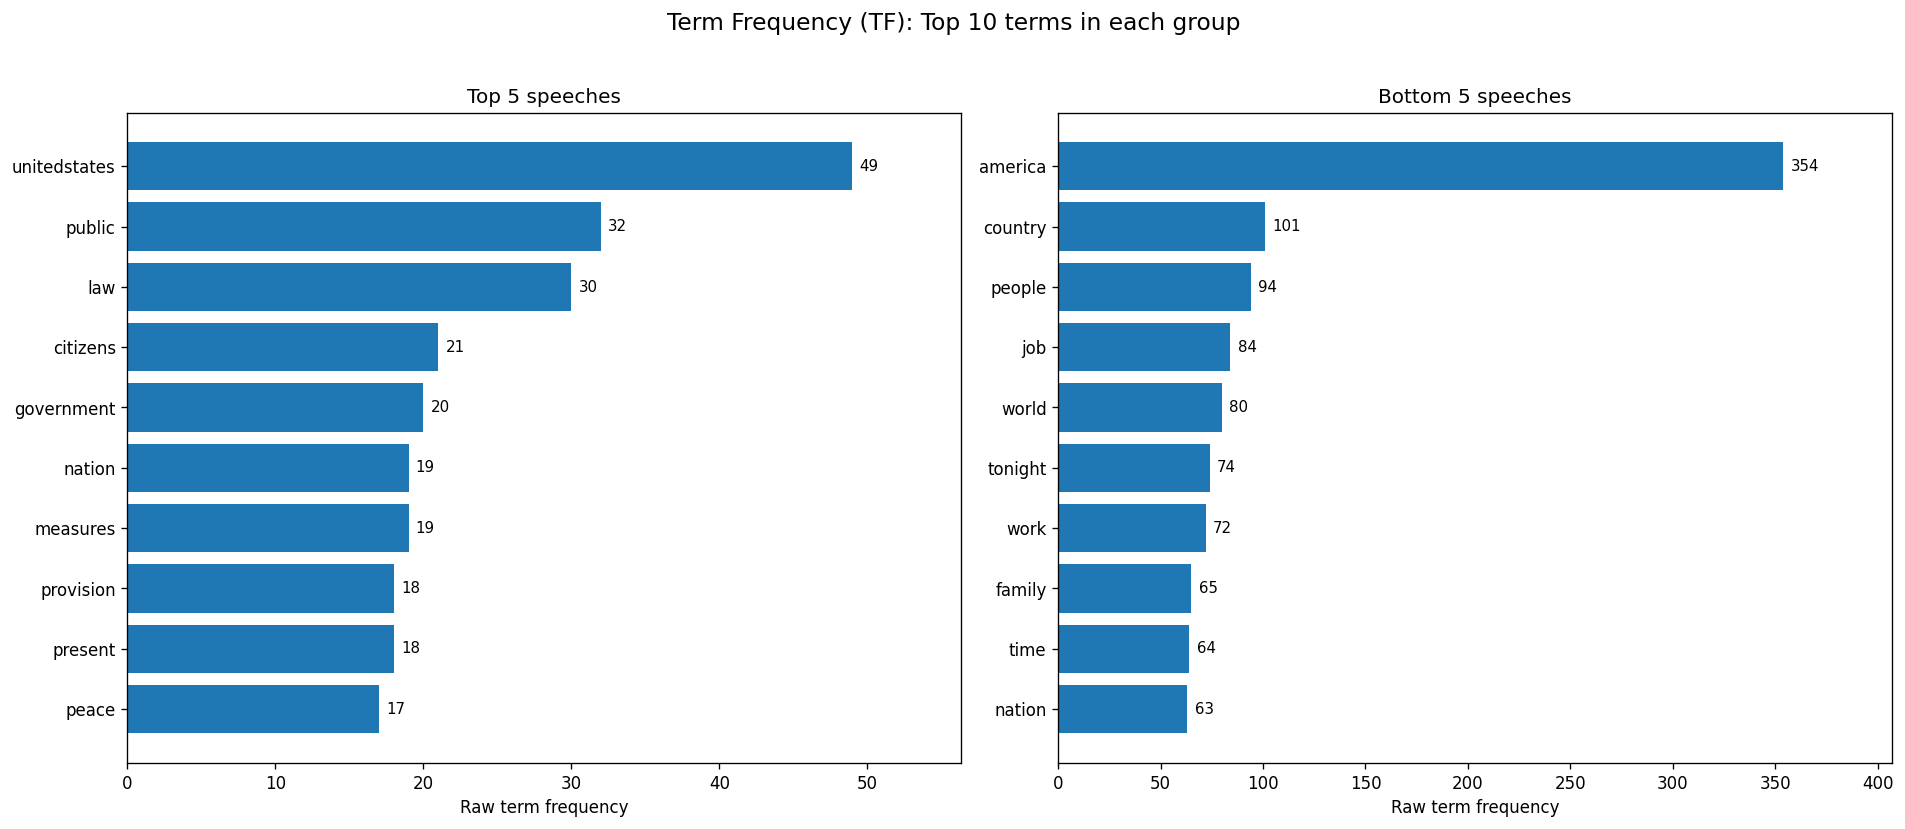

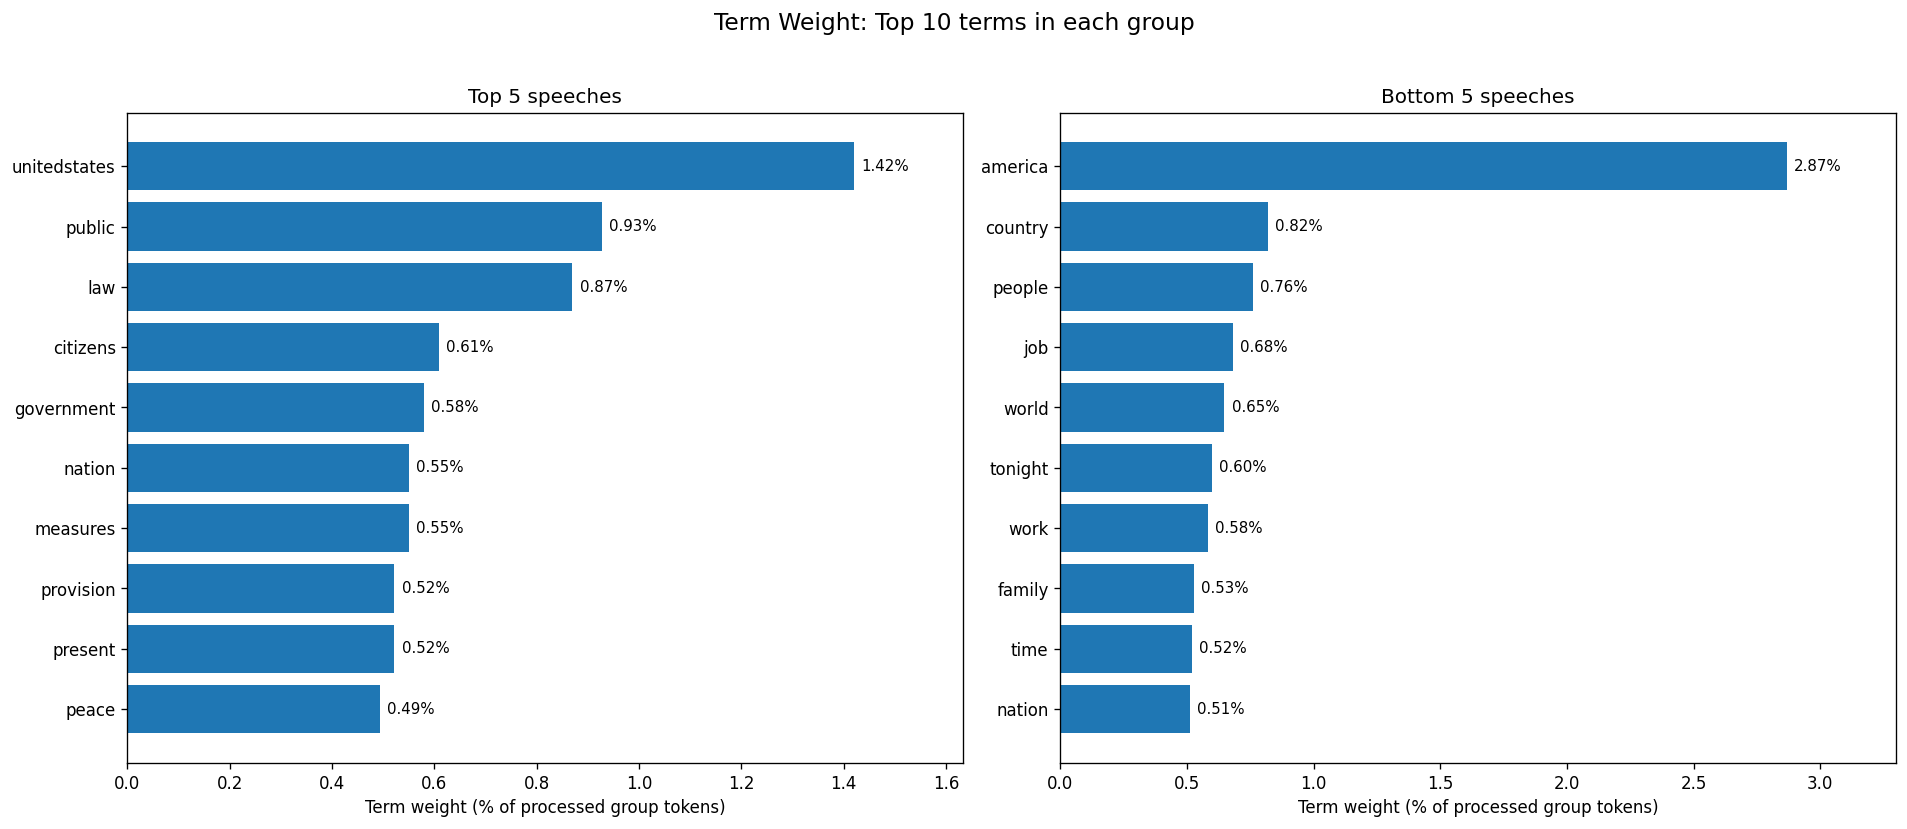

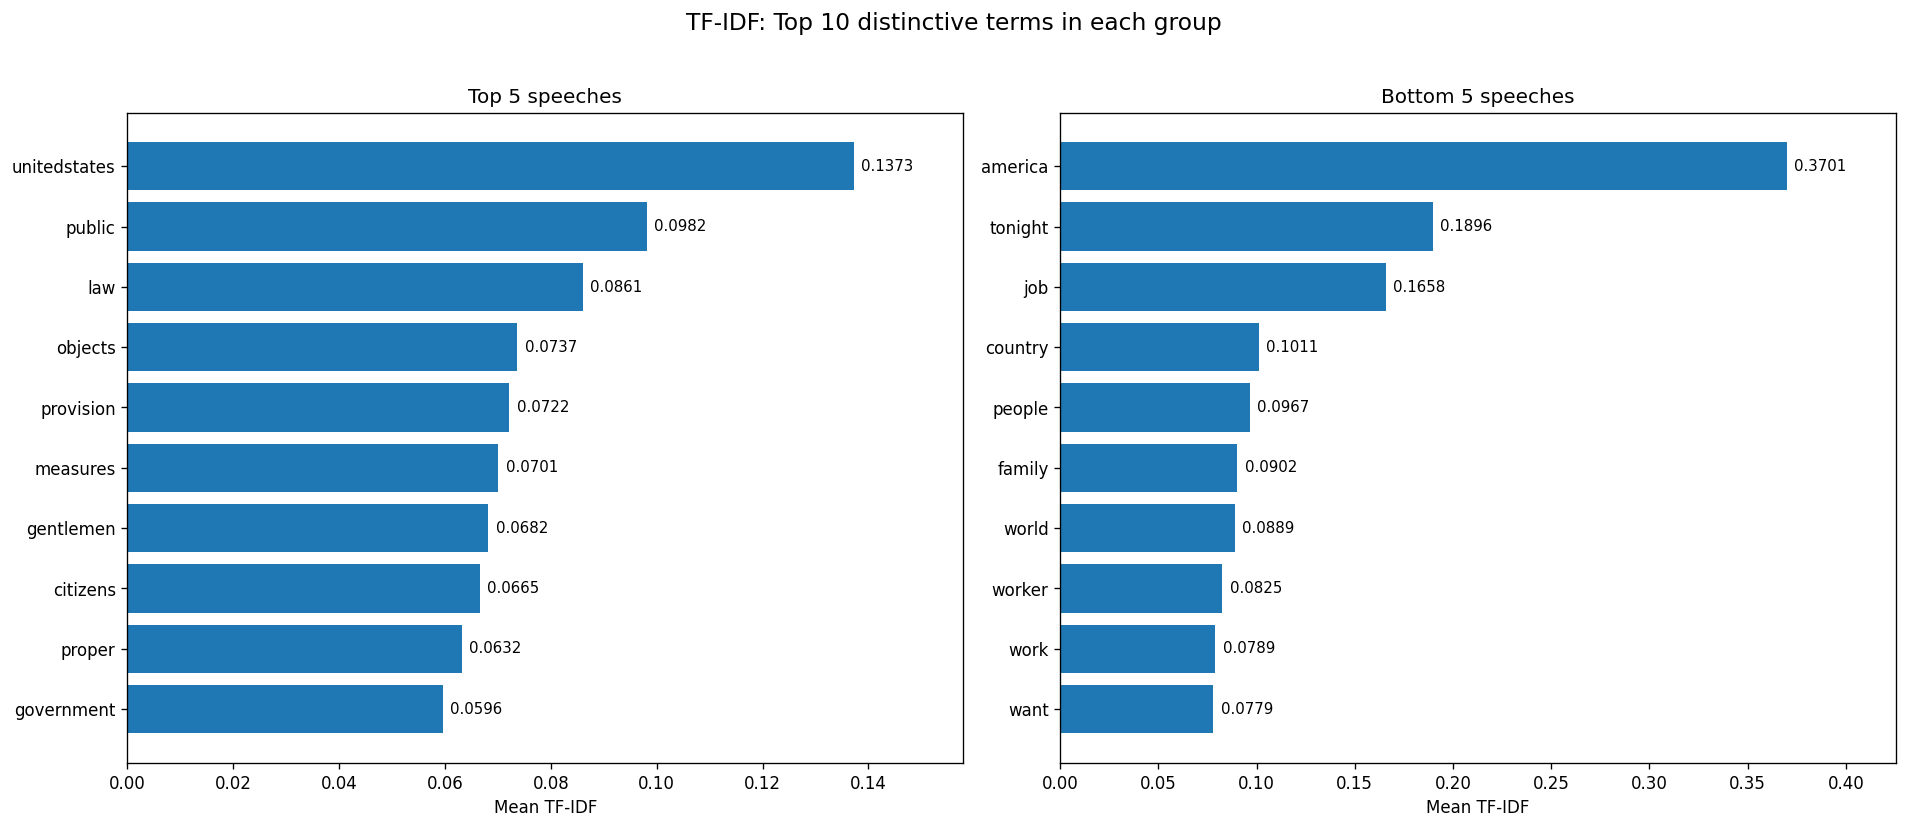

In [6]:

def plot_metric_comparison(left_df, right_df, metric_col, axis_label, figure_title, top_n=10):
    left_plot = left_df.nlargest(top_n, metric_col).sort_values(metric_col)
    right_plot = right_df.nlargest(top_n, metric_col).sort_values(metric_col)

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    axes[0].barh(left_plot["term"], left_plot[metric_col])
    axes[0].set_title("Top 5 speeches")
    axes[0].set_xlabel(axis_label)
    axes[0].margins(x=0.15)

    axes[1].barh(right_plot["term"], right_plot[metric_col])
    axes[1].set_title("Bottom 5 speeches")
    axes[1].set_xlabel(axis_label)
    axes[1].margins(x=0.15)

    for ax, plot_df in zip(axes, [left_plot, right_plot]):
        max_value = plot_df[metric_col].max()
        offset = max_value * 0.01 if max_value else 0.01
        for bar, value in zip(ax.patches, plot_df[metric_col]):
            if metric_col == "term_frequency":
                label = f"{int(value)}"
            elif metric_col == "term_weight_pct":
                label = f"{value:.2f}%"
            else:
                label = f"{value:.4f}"

            ax.text(
                bar.get_width() + offset,
                bar.get_y() + (bar.get_height() / 2),
                label,
                va="center",
                fontsize=9,
            )

    fig.suptitle(figure_title, fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

plot_metric_comparison(
    top_metrics,
    bottom_metrics,
    metric_col="term_frequency",
    axis_label="Raw term frequency",
    figure_title="Term Frequency (TF): Top 10 terms in each group",
    top_n=10,
)

plot_metric_comparison(
    top_metrics,
    bottom_metrics,
    metric_col="term_weight_pct",
    axis_label="Term weight (% of processed group tokens)",
    figure_title="Term Weight: Top 10 terms in each group",
    top_n=10,
)

plot_metric_comparison(
    top_metrics,
    bottom_metrics,
    metric_col="mean_tfidf",
    axis_label="Mean TF-IDF",
    figure_title="TF-IDF: Top 10 distinctive terms in each group",
    top_n=10,
)


## Word Clouds

The static word clouds below still use the same top/bottom groups as the original notebook, but the words are now sized from **normalized term weights** rather than raw counts.

The interactive version after that adds the requested **percentage view** so you can inspect exactly how often each displayed word appears.


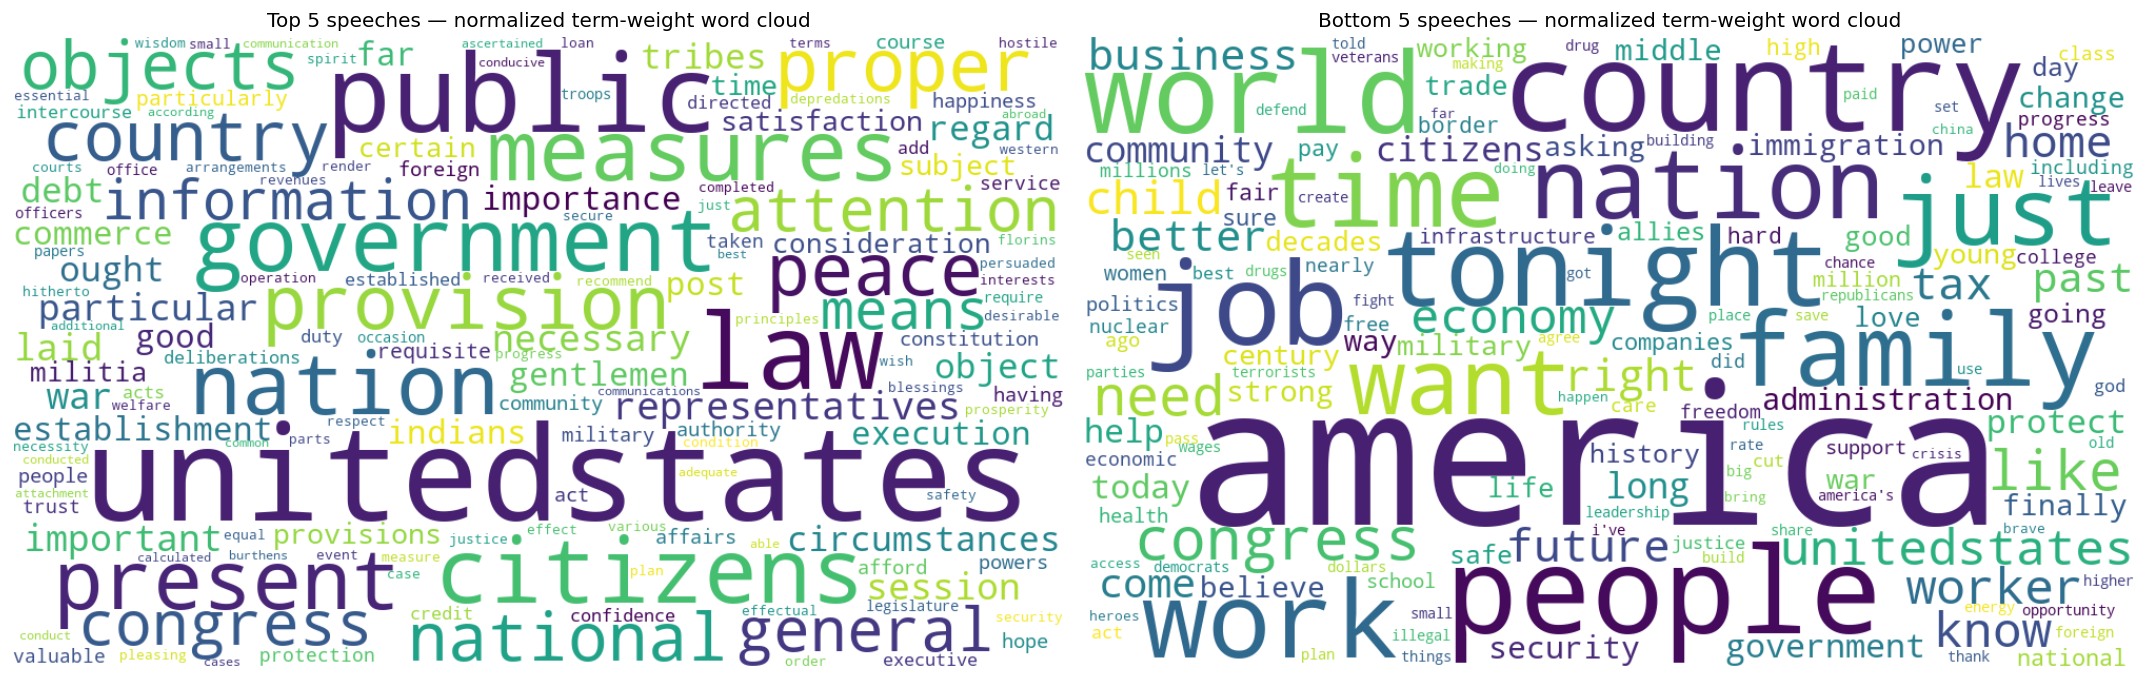

In [7]:

top_wc_freqs = dict(zip(top_metrics["term"], top_metrics["term_weight"]))
bottom_wc_freqs = dict(zip(bottom_metrics["term"], bottom_metrics["term_weight"]))

wordcloud_top = WordCloud(
    width=1000,
    height=600,
    background_color="white",
    max_words=150,
    collocations=False,
    prefer_horizontal=1.0,
    random_state=42,
).generate_from_frequencies(top_wc_freqs)

wordcloud_bottom = WordCloud(
    width=1000,
    height=600,
    background_color="white",
    max_words=150,
    collocations=False,
    prefer_horizontal=1.0,
    random_state=42,
).generate_from_frequencies(bottom_wc_freqs)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
axes[0].imshow(wordcloud_top, interpolation="bilinear")
axes[0].axis("off")
axes[0].set_title("Top 5 speeches — normalized term-weight word cloud")

axes[1].imshow(wordcloud_bottom, interpolation="bilinear")
axes[1].axis("off")
axes[1].set_title("Bottom 5 speeches — normalized term-weight word cloud")

plt.tight_layout()
plt.show()


In [8]:

top_cloud_records = (
    top_metrics.head(150)[["term", "term_frequency", "term_weight", "term_weight_pct", "mean_tfidf"]]
    .to_dict(orient="records")
)
bottom_cloud_records = (
    bottom_metrics.head(150)[["term", "term_frequency", "term_weight", "term_weight_pct", "mean_tfidf"]]
    .to_dict(orient="records")
)

top_cloud_json = json.dumps(top_cloud_records)
bottom_cloud_json = json.dumps(bottom_cloud_records)

all_pct_values = (
    [row["term_weight_pct"] for row in top_cloud_records]
    + [row["term_weight_pct"] for row in bottom_cloud_records]
)
cloud_min_pct = min(all_pct_values)
cloud_max_pct = max(all_pct_values)

import urllib.request as _ur

def _fetch(url):
    with _ur.urlopen(url) as r:
        return r.read().decode("utf-8")

_d3_js       = _fetch("https://cdnjs.cloudflare.com/ajax/libs/d3/7.8.5/d3.min.js")
_d3cloud_js  = _fetch("https://unpkg.com/d3-cloud@1.2.5/build/d3.layout.cloud.js")

html = f'''
<script>{_d3_js}</script>
<script>{_d3cloud_js}</script>

<style>
.wordcloud-grid {{
    display: grid;
    grid-template-columns: 1fr 1fr;
    gap: 24px;
    align-items: start;
}}
.wordcloud-card {{
    border: 1px solid #dddddd;
    border-radius: 10px;
    padding: 10px;
    background: #ffffff;
}}
.wordcloud-title {{
    text-align: center;
    font-family: sans-serif;
    font-size: 18px;
    margin: 6px 0 10px 0;
}}
.wordcloud-note {{
    font-family: sans-serif;
    margin-bottom: 14px;
}}
#cloud-tooltip {{
    position: fixed;
    display: none;
    z-index: 9999;
    max-width: 260px;
    font-family: sans-serif;
    font-size: 13px;
    line-height: 1.35;
    color: white;
    background: rgba(0, 0, 0, 0.9);
    border-radius: 8px;
    padding: 10px 12px;
    pointer-events: none;
    box-shadow: 0 6px 18px rgba(0,0,0,0.25);
}}
</style>

<div class="wordcloud-note">
  <b>Interactive word clouds:</b> hover over any word to see its
  raw count, normalized term weight, percentage of processed group tokens,
  and mean TF-IDF score.
</div>

<div id="cloud-tooltip"></div>

<div class="wordcloud-grid">
  <div class="wordcloud-card">
    <div class="wordcloud-title">Top 5 speeches</div>
    <svg id="wc-top" width="760" height="520"></svg>
  </div>
  <div class="wordcloud-card">
    <div class="wordcloud-title">Bottom 5 speeches</div>
    <svg id="wc-bottom" width="760" height="520"></svg>
  </div>
</div>

<script>
const cloudTooltip = d3.select("#cloud-tooltip");
const cloudMinPct = {cloud_min_pct};
const cloudMaxPct = {cloud_max_pct};
const palette = ["#1f77b4", "#ff7f0e", "#2ca02c", "#9467bd", "#8c564b", "#17becf"];

function fontScale(termPct) {{
    if (cloudMaxPct === cloudMinPct) return 28;
    return 12 + ((termPct - cloudMinPct) / (cloudMaxPct - cloudMinPct)) * 76;
}}

function showTooltip(event, d) {{
    cloudTooltip
        .style("display", "block")
        .style("left", (event.clientX + 14) + "px")
        .style("top", (event.clientY - 18) + "px")
        .html(
            "<b>" + d.text + "</b><br>" +
            "TF: " + d.term_frequency + "<br>" +
            "Term Weight: " + d.term_weight.toFixed(4) + "<br>" +
            "% of Group Tokens: " + d.term_weight_pct.toFixed(2) + "%<br>" +
            "Mean TF-IDF: " + d.mean_tfidf.toFixed(4)
        );
}}

function hideTooltip() {{
    cloudTooltip.style("display", "none");
}}

function renderCloud(words, svgId) {{
    const enriched = words.map((d) => ({{ ...d, text: d.term, size: fontScale(d.term_weight_pct) }}));

    d3.layout.cloud()
        .size([760, 520])
        .words(enriched)
        .padding(4)
        .rotate(() => 0)
        .font("sans-serif")
        .fontSize((d) => d.size)
        .on("end", function(placed) {{
            const svg = d3.select("#" + svgId);
            svg.selectAll("*").remove();

            const group = svg.append("g").attr("transform", "translate(380,260)");

            group.selectAll("text")
                .data(placed)
                .enter()
                .append("text")
                .style("font-family", "sans-serif")
                .style("font-size", (d) => d.size + "px")
                .style("fill", (d, i) => palette[i % palette.length])
                .attr("text-anchor", "middle")
                .attr("transform", (d) => "translate(" + [d.x, d.y] + ")rotate(" + d.rotate + ")")
                .text((d) => d.text)
                .on("mouseover", showTooltip)
                .on("mousemove", showTooltip)
                .on("mouseout", hideTooltip);
        }})
        .start();
}}

renderCloud({top_cloud_json}, "wc-top");
renderCloud({bottom_cloud_json}, "wc-bottom");
</script>
'''

display(HTML(html))


## Zipf's Law

Zipf's Law predicts that in natural language the *r*-th most frequent word appears roughly 
proportional to **1/r**.  On a log–log plot this means the observed points should hug a 
straight line with slope **−1** (shown in red).  Steeper drop-offs indicate a more 
concentrated vocabulary; shallower drops indicate more uniform usage.

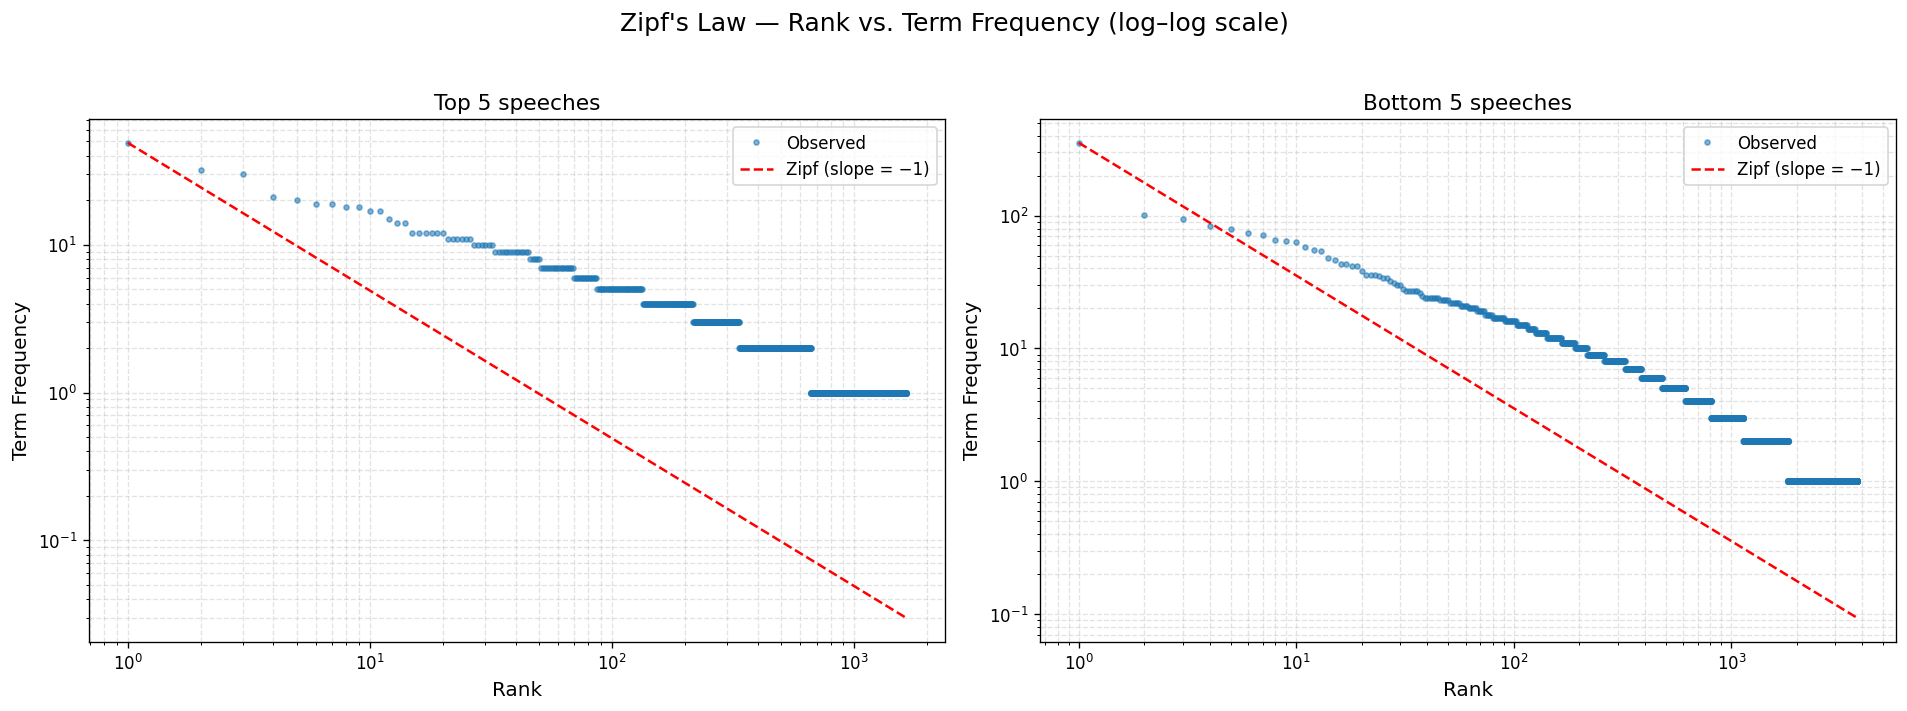

In [9]:
# Zipf's Law: rank vs. term frequency on a log-log scale.
# If a corpus follows Zipf's Law the points should fall along a line with slope ≈ -1.

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, metrics, title in zip(
    axes,
    [top_metrics, bottom_metrics],
    ["Top 5 speeches", "Bottom 5 speeches"],
):
    sorted_m = metrics.sort_values("term_frequency", ascending=False).reset_index(drop=True)
    ranks = sorted_m.index + 1
    freqs = sorted_m["term_frequency"]

    ax.loglog(ranks, freqs, "o", markersize=3, alpha=0.55, label="Observed")

    # Theoretical Zipf line scaled to the most-frequent term
    zipf_line = freqs.iloc[0] / ranks
    ax.loglog(ranks, zipf_line, "--", color="red", linewidth=1.5, label="Zipf (slope = −1)")

    ax.set_xlabel("Rank", fontsize=12)
    ax.set_ylabel("Term Frequency", fontsize=12)
    ax.set_title(title, fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, which="both", linestyle="--", alpha=0.35)

fig.suptitle("Zipf's Law — Rank vs. Term Frequency (log–log scale)", fontsize=15)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
